# 📱 Cell2Cell Telecom — Churn Prediction
## World-Class End-to-End ML Pipeline

| Property | Value |
|---|---|
| Dataset | Cell2Cell Telecom |
| Rows | 51,047 |
| Features | 57 raw → 85+ after engineering |
| Target | Binary: `Churn` (Yes/No) |

### What makes this world-class
- **Target encoding** for ServiceArea (747 unique levels)
- **22+ engineered features** capturing business signals
- **4 gradient boosting models** (XGBoost, LightGBM, CatBoost, RF)
- **Optuna TPE** hyperparameter tuning (60 trials each)
- **5-fold OOF Stacking Ensemble** with LR meta-learner
- **Business ROI analysis**: lift curves, cost curves, risk segmentation


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px, plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve
import xgboost as xgb, lightgbm as lgb, catboost as cb
import category_encoders as ce
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import json, pickle
from IPython.display import display

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi':120,'font.size':11})
SEED = 42; np.random.seed(SEED)
print('All imports OK')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | CatBoost {cb.__version__}')


All imports OK
XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost 1.2.10


In [2]:
df = pd.read_csv('cell2celltrain.csv')
df['y'] = (df['Churn'] == 'Yes').astype(int)
print('='*55)
print(f'  Rows     : {len(df):,}')
print(f'  Columns  : {df.shape[1]}')
print(f'  Churners : {df["y"].sum():,} ({df["y"].mean():.1%})')
print(f'  Nulls    : {df.isnull().sum().sum():,}')
print('='*55)
display(df.head(3))


  Rows     : 51,047
  Columns  : 59
  Churners : 14,711 (28.8%)
  Nulls    : 3,515


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,y
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,4,No,0,30,Yes,1-Highest,Suburban,Professional,No,1
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,5,No,0,30,No,4-Medium,Suburban,Professional,Yes,1
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes,0


In [3]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Churn Distribution','Churn Rate by Credit Rating'),
    specs=[[{'type':'pie'},{'type':'bar'}]])
counts = df['Churn'].value_counts()
fig.add_trace(go.Pie(labels=counts.index, values=counts.values, hole=0.5,
    marker_colors=['#2ecc71','#e74c3c'], textinfo='label+percent+value'), row=1, col=1)
credit_order = ['1-Highest','2-High','3-Good','4-Medium','5-Low','6-VeryLow','7-Lowest']
cr = df.groupby('CreditRating')['y'].mean().reindex(credit_order)
fig.add_trace(go.Bar(x=cr.index, y=cr.values*100,
    text=[f'{v:.1f}%' for v in cr.values*100], textposition='auto',
    marker_color=px.colors.sequential.RdBu_r[:7]), row=1, col=2)
fig.update_layout(title='<b>Churn Overview</b>', height=420, template='plotly_white', showlegend=False)
fig.show()


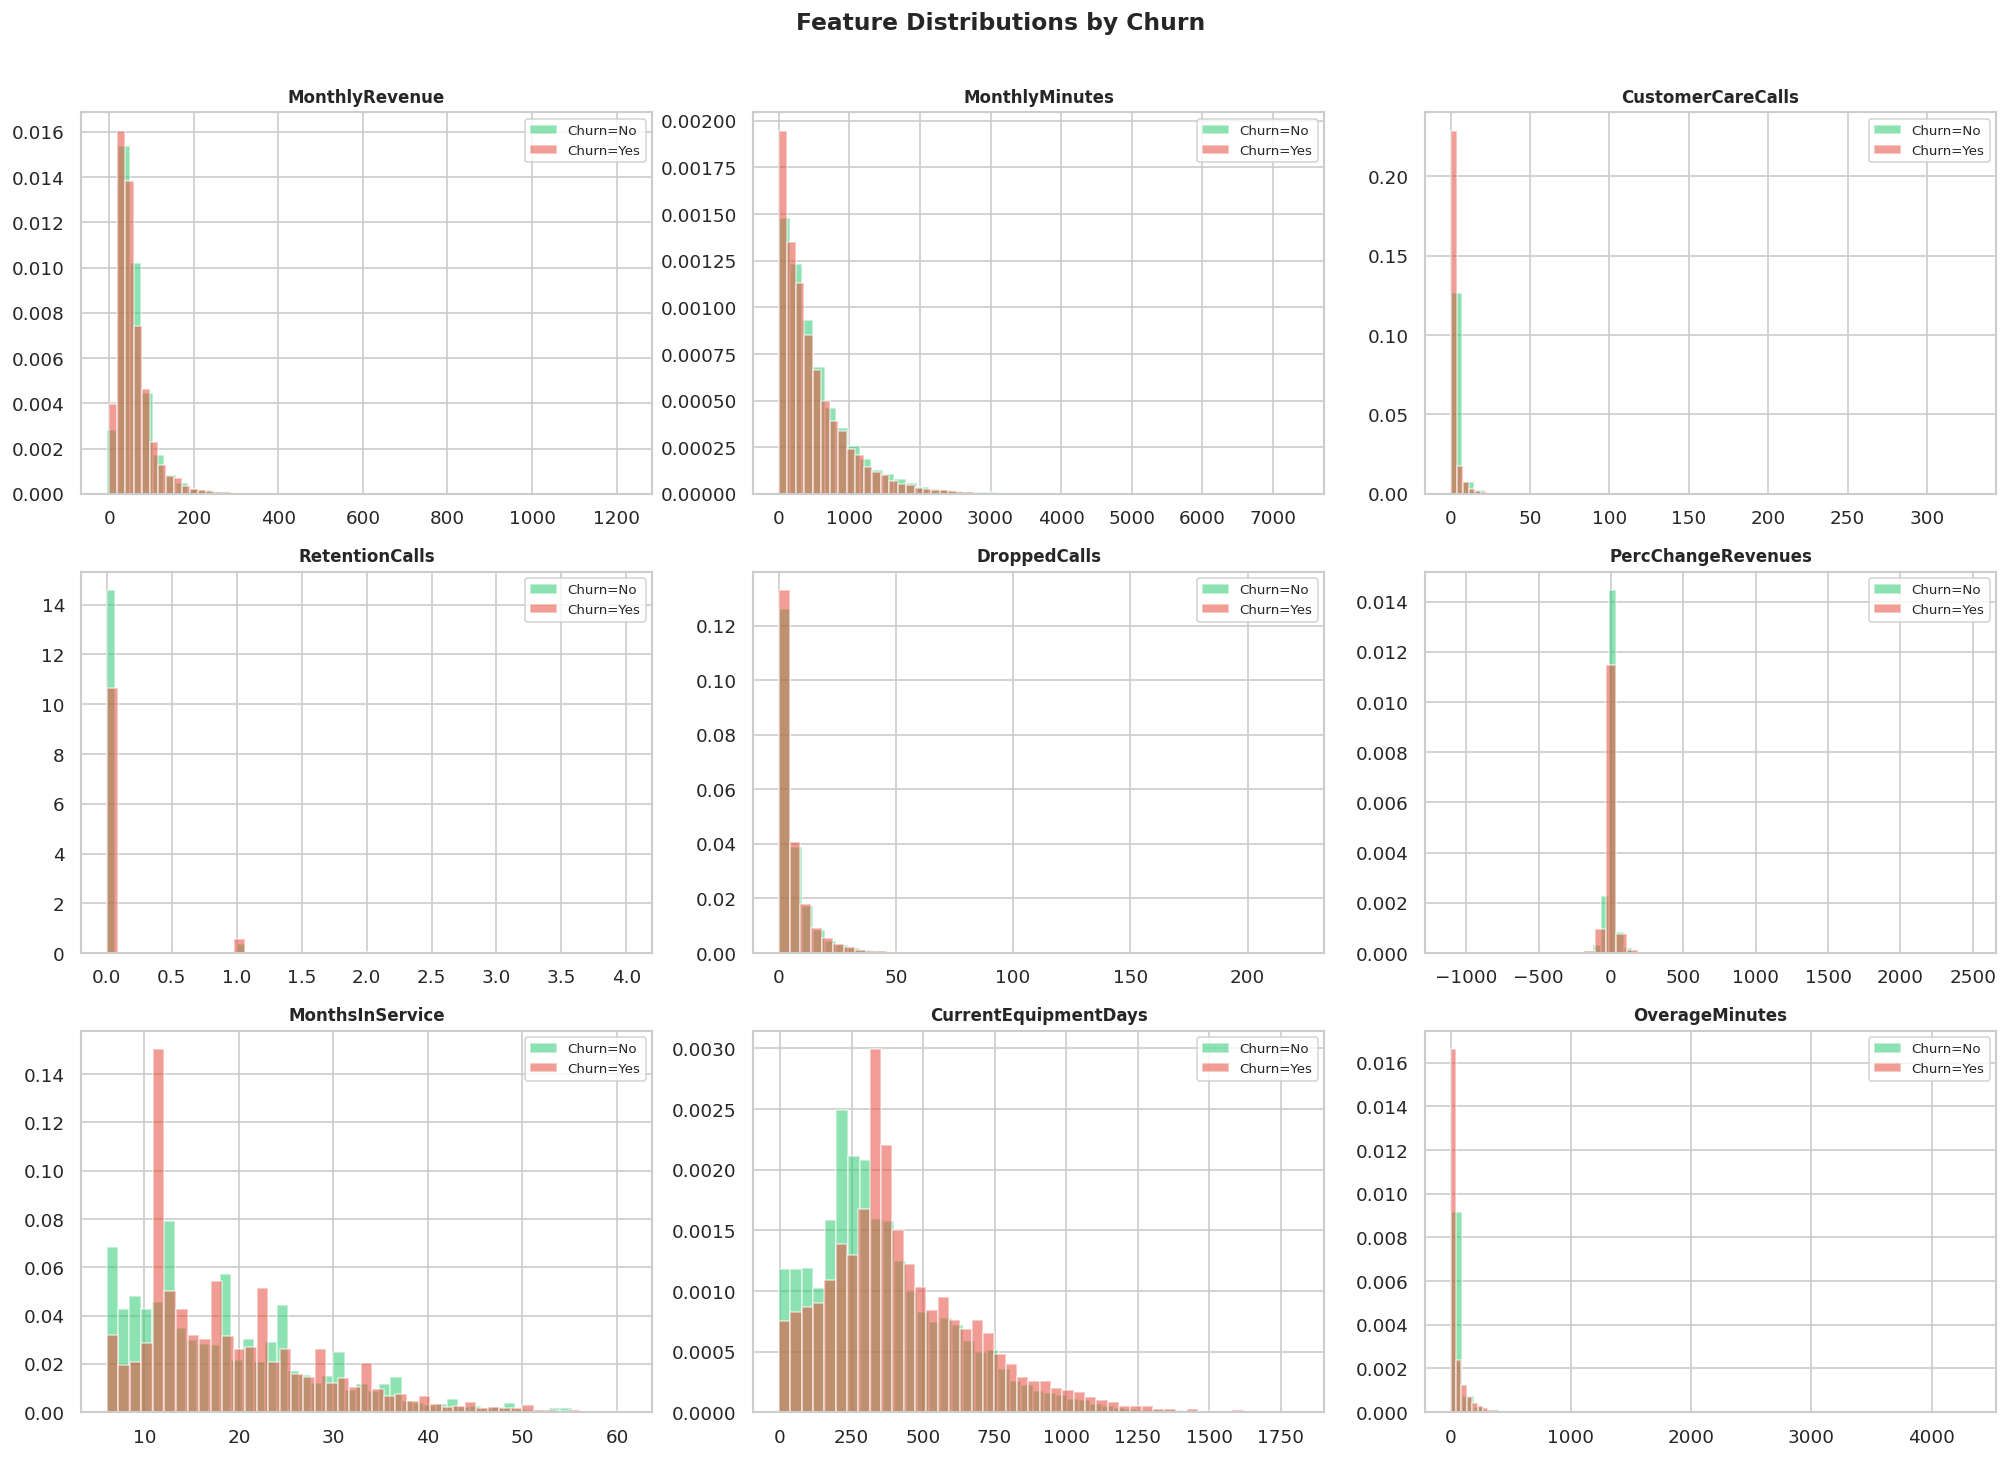

In [4]:
cols = ['MonthlyRevenue','MonthlyMinutes','CustomerCareCalls','RetentionCalls',
        'DroppedCalls','PercChangeRevenues','MonthsInService','CurrentEquipmentDays','OverageMinutes']
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
for ax, col in zip(axes.flatten(), cols):
    for lbl, clr in [('No','#2ecc71'),('Yes','#e74c3c')]:
        ax.hist(df[df['Churn']==lbl][col].dropna(), bins=45,
                alpha=0.55, color=clr, density=True, label=f'Churn={lbl}')
    ax.set_title(col, fontweight='bold', fontsize=10); ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


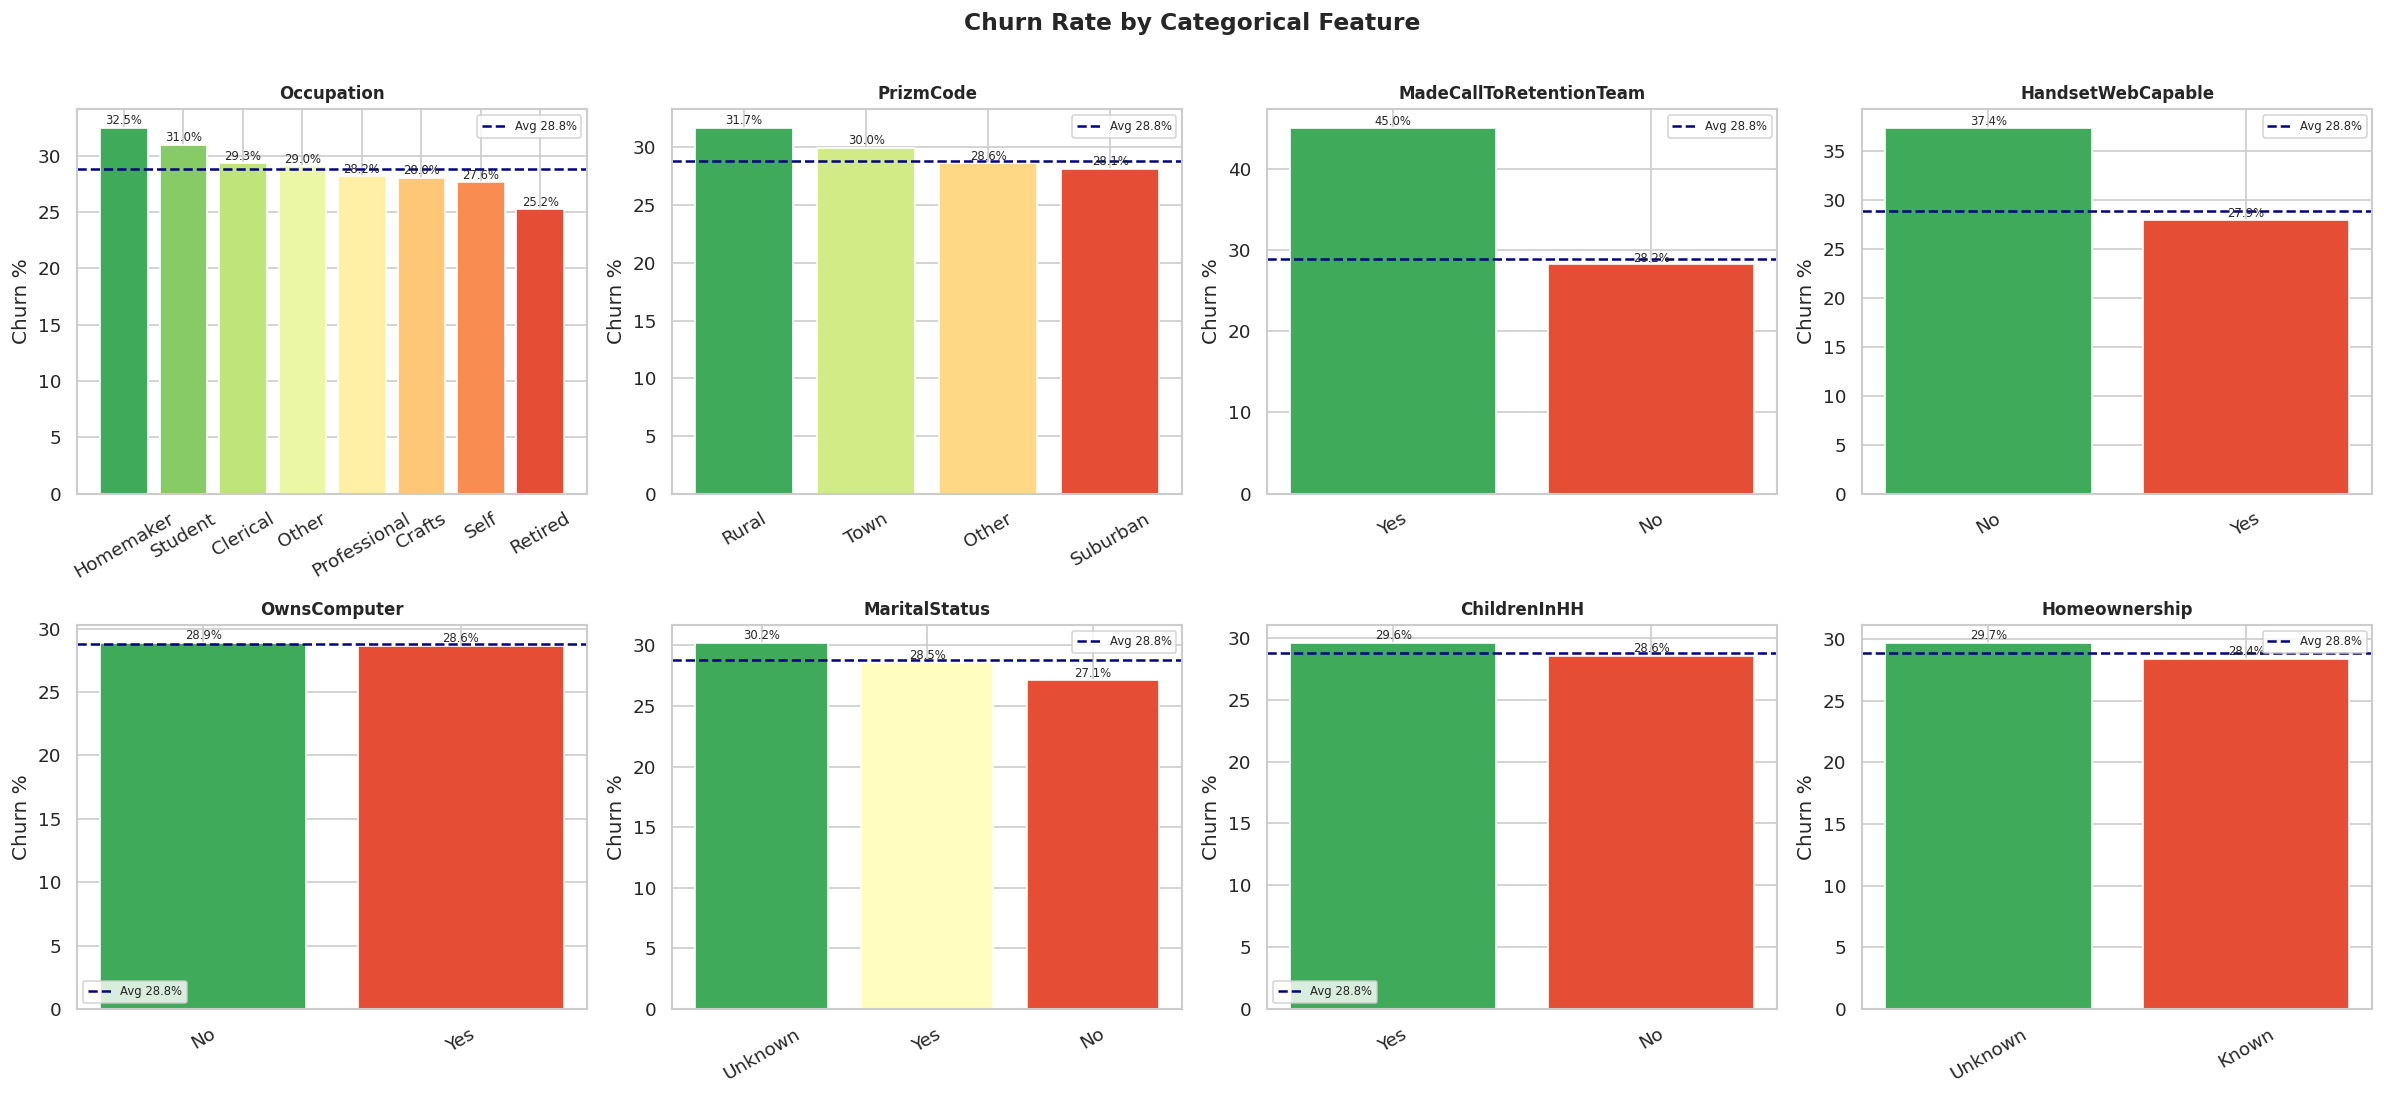

In [5]:
cat_cols = ['Occupation','PrizmCode','MadeCallToRetentionTeam',
            'HandsetWebCapable','OwnsComputer','MaritalStatus','ChildrenInHH','Homeownership']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    cr2 = df.groupby(col)['y'].mean().sort_values(ascending=False)
    clrs = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(cr2)))
    bars = ax.bar(cr2.index, cr2.values*100, color=clrs, edgecolor='white')
    ax.axhline(df['y'].mean()*100, color='navy', ls='--', lw=1.5, label=f'Avg {df["y"].mean():.1%}')
    ax.set_title(col, fontweight='bold', fontsize=10); ax.set_ylabel('Churn %')
    ax.legend(fontsize=7)
    for b, v in zip(bars, cr2.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1%}', ha='center', fontsize=7)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


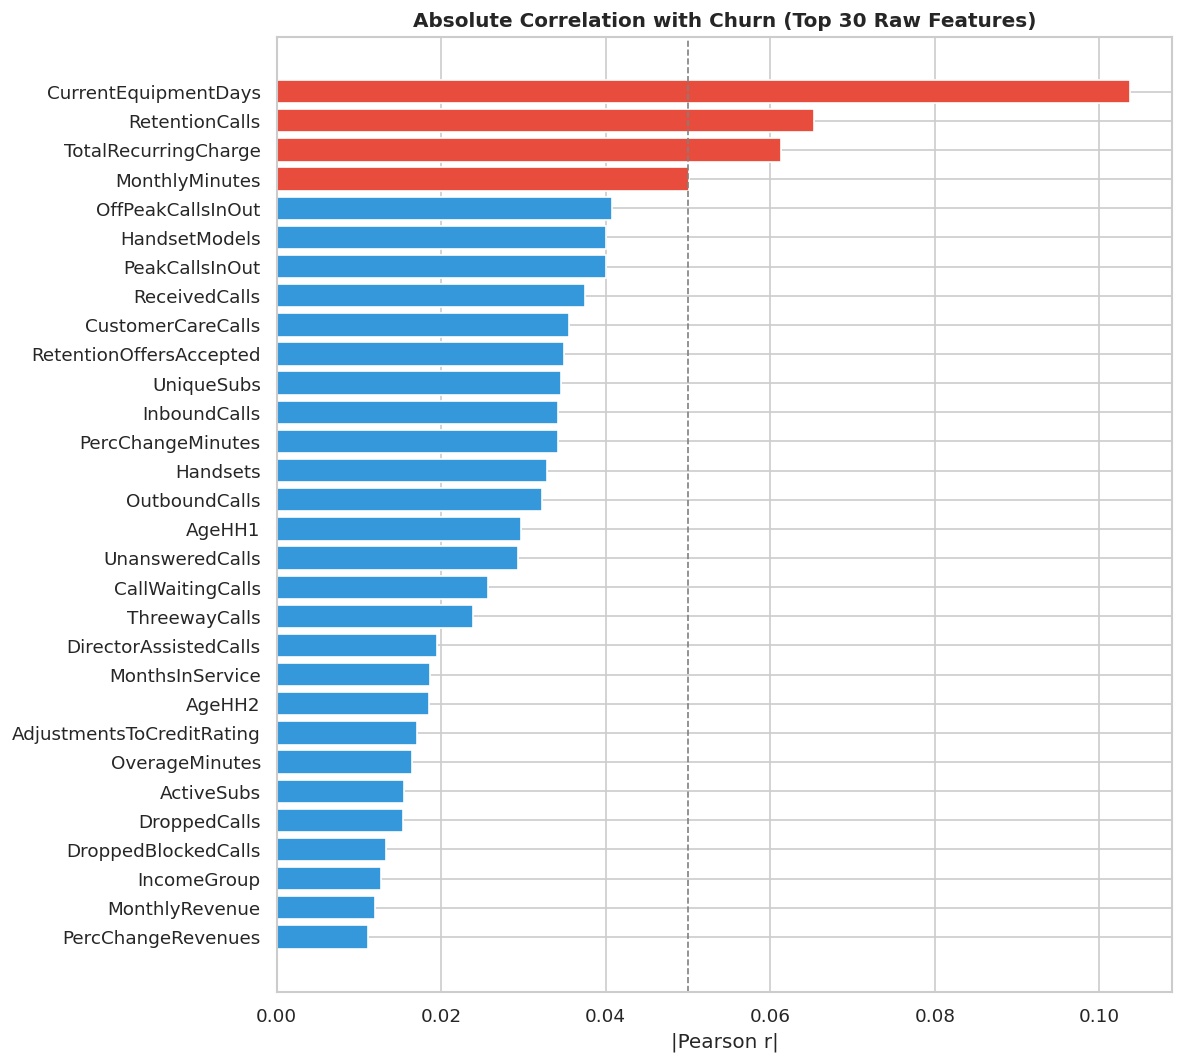

Top 10:
CurrentEquipmentDays       0.103688
RetentionCalls             0.065301
TotalRecurringCharge       0.061296
MonthlyMinutes             0.050166
OffPeakCallsInOut          0.040784
HandsetModels              0.040048
PeakCallsInOut             0.040029
ReceivedCalls              0.037453
CustomerCareCalls          0.035510
RetentionOffersAccepted    0.034953


In [6]:
num_df = df.select_dtypes(include=np.number).drop(['CustomerID','y'], axis=1, errors='ignore')
corr = num_df.corrwith(df['y']).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 9))
top30 = corr.head(30)
ax.barh(top30.index[::-1], top30.values[::-1],
        color=['#e74c3c' if v > 0.05 else '#3498db' for v in top30.values][::-1])
ax.axvline(0.05, color='gray', ls='--', lw=1)
ax.set_title('Absolute Correlation with Churn (Top 30 Raw Features)', fontweight='bold', fontsize=12)
ax.set_xlabel('|Pearson r|'); plt.tight_layout(); plt.show()
print('Top 10:'); print(corr.head(10).to_string())


## 2. Feature Engineering


In [7]:
def engineer_features(df):
    d = df.copy(); e = 1e-6
    # Revenue / usage
    d['RevenuePerMinute']   = d['MonthlyRevenue'] / (d['MonthlyMinutes'] + e)
    d['ChargeRatio']        = d['TotalRecurringCharge'] / (d['MonthlyRevenue'] + e)
    d['OverageRatio']       = d['OverageMinutes'] / (d['MonthlyMinutes'] + e)
    d['RoamingRatio']       = d['RoamingCalls'] / (d['MonthlyMinutes'] + e)
    # Call quality
    d['DropBlockSum']       = d['DroppedCalls'] + d['BlockedCalls']
    d['DropBlockRatio']     = d['DropBlockSum'] / (d['MonthlyMinutes'] + e)
    # Retention signals (strongest)
    d['RetentionEngaged']   = (d['RetentionCalls'] > 0).astype(int)
    d['OfferAcceptRate']    = d['RetentionOffersAccepted'] / (d['RetentionCalls'] + e)
    d['RetentionFailed']    = ((d['RetentionCalls'] > 0) & (d['RetentionOffersAccepted'] == 0)).astype(int)
    d['CareCalls_PerMonth'] = d['CustomerCareCalls'] / (d['MonthsInService'] + e)
    # Usage change
    d['RevenueDecline']     = (d['PercChangeRevenues'] < -10).astype(int)
    d['MinsDecline']        = (d['PercChangeMinutes'] < -20).astype(int)
    d['BothDecline']        = d['RevenueDecline'] * d['MinsDecline']
    d['RevenueChangeSq']    = d['PercChangeRevenues'] ** 2
    # Device / tenure
    d['HandsetAgeMonths']   = d['CurrentEquipmentDays'] / 30
    d['TenureEquipRatio']   = d['MonthsInService'] / (d['CurrentEquipmentDays'] + e)
    d['MonthsInService_sq'] = np.sqrt(d['MonthsInService'].clip(0))
    # Credit
    cmap = {'1-Highest':7,'2-High':6,'3-Good':5,'4-Medium':4,'5-Low':3,'6-VeryLow':2,'7-Lowest':1}
    d['CreditScore']        = d['CreditRating'].map(cmap)
    d['LowCredit']          = (d['CreditScore'] <= 3).astype(int)
    # HandsetPrice
    d['HandsetPriceNum']    = pd.to_numeric(d['HandsetPrice'].replace('Unknown', np.nan))
    d['HandsetPriceUnknown']= (d['HandsetPrice'] == 'Unknown').astype(int)
    # Household
    d['AvgHHAge']           = d[['AgeHH1','AgeHH2']].mean(axis=1)
    # Interactions
    d['LowCredit_HighCare'] = d['LowCredit'] * (d['CustomerCareCalls'] > 2).astype(int)
    d['RetFail_LowCredit']  = d['RetentionFailed'] * d['LowCredit']
    d['HighCare_Decline']   = (d['CustomerCareCalls'] > 2).astype(int) * d['RevenueDecline']
    d['PeakOffPeakRatio']   = d['PeakCallsInOut'] / (d['OffPeakCallsInOut'] + e)
    return d

df_feat = engineer_features(df)
new_cols = set(df_feat.columns) - set(df.columns)
print(f'Feature engineering: {len(df.columns)} -> {len(df_feat.columns)} features ({len(new_cols)} new)')


Feature engineering: 59 -> 85 features (26 new)


## 3. Preprocessing (Target Encoding for ServiceArea)


In [8]:
DROP_COLS = ['CustomerID','Churn','y','CreditRating','HandsetPrice']
BINARY_COLS = ['ChildrenInHH','HandsetRefurbished','HandsetWebCapable','TruckOwner','RVOwner',
               'BuysViaMailOrder','RespondsToMailOffers','OptOutMailings','NonUSTravel',
               'OwnsComputer','HasCreditCard','NewCellphoneUser','NotNewCellphoneUser',
               'OwnsMotorcycle','MadeCallToRetentionTeam']
BIN_MAP = {'Yes':1,'No':0,'Unknown':-1,'Known':1}

def preprocess(df_in, y_ser=None, te=None, le=None, meds=None, fit=True):
    d = df_in.copy()
    for col in BINARY_COLS:
        if col in d.columns: d[col] = d[col].map(BIN_MAP).fillna(0).astype(int)
    if 'MaritalStatus' in d.columns: d['MaritalStatus'] = (d['MaritalStatus']=='Yes').astype(int)
    if 'Homeownership' in d.columns: d['Homeownership'] = (d['Homeownership']=='Known').astype(int)
    # Target-encode ServiceArea (fit on train only!)
    if 'ServiceArea' in d.columns:
        if fit:
            te = ce.TargetEncoder(cols=['ServiceArea'], smoothing=30)
            d['ServiceArea'] = te.fit_transform(d[['ServiceArea']], y_ser)['ServiceArea']
        else:
            d['ServiceArea'] = te.transform(d[['ServiceArea']])['ServiceArea']
    # Label encode remaining object cols
    cats = d.select_dtypes('object').columns.tolist()
    if fit:
        le = {}
        for col in cats:
            enc = LabelEncoder(); d[col] = enc.fit_transform(d[col].astype(str)); le[col] = enc
    else:
        for col in cats:
            if col in le:
                d[col] = d[col].astype(str).apply(lambda x: le[col].transform([x])[0] if x in le[col].classes_ else -1)
    X = d.drop(columns=DROP_COLS, errors='ignore')
    X = X.replace([np.inf,-np.inf], np.nan)
    if fit: meds = X.median()
    X = X.fillna(meds).fillna(0).clip(-1e9, 1e9)
    return X, te, le, meds

y_full = df_feat['y']
idx_tr, idx_te = train_test_split(df_feat.index, test_size=0.20, random_state=SEED, stratify=y_full)
idx_tr, idx_va = train_test_split(idx_tr, test_size=0.15, random_state=SEED, stratify=y_full[idx_tr])

y_train, y_val, y_test = y_full[idx_tr].values, y_full[idx_va].values, y_full[idx_te].values

X_train, te_enc, le_enc, meds = preprocess(df_feat.loc[idx_tr],
    y_ser=pd.Series(y_train, index=idx_tr), fit=True)
X_val,  *_ = preprocess(df_feat.loc[idx_va], te=te_enc, le=le_enc, meds=meds, fit=False)
X_test, *_ = preprocess(df_feat.loc[idx_te], te=te_enc, le=le_enc, meds=meds, fit=False)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

SCALE_POS = (y_train==0).sum() / (y_train==1).sum()

print(f'Train  : {len(y_train):,}  ({y_train.mean():.1%} churn)')
print(f'Val    : {len(y_val):,}  ({y_val.mean():.1%} churn)')
print(f'Test   : {len(y_test):,}  ({y_test.mean():.1%} churn)')
print(f'Features: {X_train.shape[1]}')
print(f'NaN: {X_train.isnull().sum().sum()} | Inf: {np.isinf(X_train.values).sum()}')


Train  : 34,711  (28.8% churn)
Val    : 6,126  (28.8% churn)
Test   : 10,210  (28.8% churn)
Features: 80
NaN: 0 | Inf: 0


## 4. Model Training


In [9]:
results = {}
def record(name, pv, pt, model=None):
    pred = (pt>=0.5).astype(int)
    results[name] = dict(model=model, prob_test=pt,
        val_auc=roc_auc_score(y_val,pv), test_auc=roc_auc_score(y_test,pt),
        f1=f1_score(y_test,pred), precision=precision_score(y_test,pred),
        recall=recall_score(y_test,pred), ap=average_precision_score(y_test,pt))
    r=results[name]
    print(f'  {name:38s}| Val {r["val_auc"]:.4f} | Test {r["test_auc"]:.4f} | F1 {r["f1"]:.4f} | AP {r["ap"]:.4f}')

print('Baseline models:')
print('-'*90)

lr = LogisticRegression(C=0.05, class_weight='balanced', max_iter=1000, random_state=SEED)
lr.fit(X_train_s, y_train)
record('Logistic Regression', lr.predict_proba(X_val_s)[:,1], lr.predict_proba(X_test_s)[:,1], lr)

rf = RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=15,
    class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
record('Random Forest', rf.predict_proba(X_val)[:,1], rf.predict_proba(X_test)[:,1], rf)

xgb0 = xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=SCALE_POS, eval_metric='auc', early_stopping_rounds=50,
    random_state=SEED, verbosity=0)
xgb0.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
record('XGBoost (base)', xgb0.predict_proba(X_val)[:,1], xgb0.predict_proba(X_test)[:,1], xgb0)

lgbm0 = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    class_weight='balanced', random_state=SEED, verbose=-1, early_stopping_round=50)
lgbm0.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
record('LightGBM (base)', lgbm0.predict_proba(X_val)[:,1], lgbm0.predict_proba(X_test)[:,1], lgbm0)

catb0 = cb.CatBoostClassifier(iterations=800, learning_rate=0.05, depth=7,
    scale_pos_weight=SCALE_POS, eval_metric='AUC', early_stopping_rounds=50,
    random_seed=SEED, verbose=0)
catb0.fit(X_train, y_train, eval_set=(X_val,y_val))
record('CatBoost (base)', catb0.predict_proba(X_val)[:,1], catb0.predict_proba(X_test)[:,1], catb0)


Baseline models:
------------------------------------------------------------------------------------------


  Logistic Regression                   | Val 0.5448 | Test 0.5452 | F1 0.4043 | AP 0.3343


  Random Forest                         | Val 0.6713 | Test 0.6610 | F1 0.4642 | AP 0.4328


  XGBoost (base)                        | Val 0.6741 | Test 0.6668 | F1 0.4799 | AP 0.4437


  LightGBM (base)                       | Val 0.6650 | Test 0.6599 | F1 0.4426 | AP 0.4347


  CatBoost (base)                       | Val 0.6711 | Test 0.6686 | F1 0.4772 | AP 0.4430


## 5. Hyperparameter Tuning (Optuna)


In [10]:
print('Optuna — XGBoost (60 trials)...')
def xgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',300,1200),
             learning_rate=trial.suggest_float('lr',0.01,0.15,log=True),
             max_depth=trial.suggest_int('max_depth',4,9),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
             min_child_weight=trial.suggest_int('min_child_weight',1,30),
             gamma=trial.suggest_float('gamma',0,3),
             reg_alpha=trial.suggest_float('reg_alpha',1e-8,5.0,log=True),
             reg_lambda=trial.suggest_float('reg_lambda',1e-8,5.0,log=True),
             scale_pos_weight=SCALE_POS, eval_metric='auc',
             random_state=SEED, verbosity=0)
    m = xgb.XGBClassifier(**p, early_stopping_rounds=40)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_obj, n_trials=60, show_progress_bar=True)
print(f'Best XGBoost Val AUC: {study_xgb.best_value:.4f}')


Optuna — XGBoost (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best XGBoost Val AUC: 0.6758


In [11]:
print('Optuna — LightGBM (60 trials)...')
def lgbm_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',300,2500),
             learning_rate=trial.suggest_float('lr',0.005,0.15,log=True),
             max_depth=trial.suggest_int('max_depth',4,10),
             num_leaves=trial.suggest_int('num_leaves',20,255),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
             min_child_samples=trial.suggest_int('min_child_samples',5,100),
             reg_alpha=trial.suggest_float('reg_alpha',1e-8,5.0,log=True),
             reg_lambda=trial.suggest_float('reg_lambda',1e-8,5.0,log=True),
             class_weight='balanced', random_state=SEED, verbose=-1, early_stopping_round=40)
    m = lgb.LGBMClassifier(**p)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_obj, n_trials=60, show_progress_bar=True)
print(f'Best LightGBM Val AUC: {study_lgbm.best_value:.4f}')


Optuna — LightGBM (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best LightGBM Val AUC: 0.6763


In [12]:
print('Optuna — CatBoost (40 trials)...')
def catb_obj(trial):
    p = dict(iterations=trial.suggest_int('iterations',300,1500),
             learning_rate=trial.suggest_float('lr',0.01,0.2,log=True),
             depth=trial.suggest_int('depth',4,10),
             l2_leaf_reg=trial.suggest_float('l2',1e-3,20.0,log=True),
             bagging_temperature=trial.suggest_float('bag_temp',0.0,2.0),
             scale_pos_weight=SCALE_POS, eval_metric='AUC',
             random_seed=SEED, verbose=0, early_stopping_rounds=40)
    m = cb.CatBoostClassifier(**p)
    m.fit(X_train, y_train, eval_set=(X_val,y_val))
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_catb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_catb.optimize(catb_obj, n_trials=40, show_progress_bar=True)
print(f'Best CatBoost Val AUC: {study_catb.best_value:.4f}')


Optuna — CatBoost (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best CatBoost Val AUC: 0.6749


In [13]:
print('Training tuned models...')

xgb_p = {**study_xgb.best_params, 'learning_rate': study_xgb.best_params.pop('lr',study_xgb.best_params.get('learning_rate',0.05))}
if 'lr' in xgb_p: xgb_p['learning_rate'] = xgb_p.pop('lr')
xgb_t = xgb.XGBClassifier(**xgb_p, scale_pos_weight=SCALE_POS,
    eval_metric='auc', random_state=SEED, verbosity=0, early_stopping_rounds=50)
xgb_t.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
record('XGBoost (Tuned)', xgb_t.predict_proba(X_val)[:,1], xgb_t.predict_proba(X_test)[:,1], xgb_t)

lgbm_p = {**study_lgbm.best_params}
if 'lr' in lgbm_p: lgbm_p['learning_rate'] = lgbm_p.pop('lr')
lgbm_t = lgb.LGBMClassifier(**lgbm_p, class_weight='balanced',
    random_state=SEED, verbose=-1, early_stopping_round=50)
lgbm_t.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
record('LightGBM (Tuned)', lgbm_t.predict_proba(X_val)[:,1], lgbm_t.predict_proba(X_test)[:,1], lgbm_t)

catb_p = {**study_catb.best_params}
if 'lr' in catb_p: catb_p['learning_rate'] = catb_p.pop('lr')
if 'l2' in catb_p: catb_p['l2_leaf_reg'] = catb_p.pop('l2')
if 'bag_temp' in catb_p: catb_p['bagging_temperature'] = catb_p.pop('bag_temp')
catb_t = cb.CatBoostClassifier(**catb_p, scale_pos_weight=SCALE_POS,
    eval_metric='AUC', random_seed=SEED, verbose=0, early_stopping_rounds=50)
catb_t.fit(X_train, y_train, eval_set=(X_val,y_val))
record('CatBoost (Tuned)', catb_t.predict_proba(X_val)[:,1], catb_t.predict_proba(X_test)[:,1], catb_t)


Training tuned models...


  XGBoost (Tuned)                       | Val 0.6758 | Test 0.6650 | F1 0.4820 | AP 0.4405


  LightGBM (Tuned)                      | Val 0.6763 | Test 0.6683 | F1 0.4739 | AP 0.4451


  CatBoost (Tuned)                      | Val 0.6749 | Test 0.6679 | F1 0.4811 | AP 0.4448


## 6. Stacking Ensemble (OOF)


In [14]:
print('Building 5-fold OOF Stacking Ensemble...')
TOP = ['XGBoost (Tuned)','LightGBM (Tuned)','CatBoost (Tuned)','Random Forest']
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_tv = pd.concat([X_train, X_val], ignore_index=True)
y_tv = np.concatenate([y_train, y_val])
oof  = np.zeros((len(X_tv), len(TOP)))
tprd = np.zeros((len(X_test), len(TOP)))

# Keys we'll supply manually — must not appear twice
SKIP = {'early_stopping_rounds','early_stopping_round','callbacks',
        'verbosity','verbose','random_state','random_seed',
        'n_jobs','device','tree_method'}

for j, mname in enumerate(TOP):
    fold_tp = np.zeros((N_FOLDS, len(X_test)))
    print(f'  {mname} OOF...')
    for fold, (tr_i, oo_i) in enumerate(skf.split(X_tv, y_tv)):
        Xf, yf = X_tv.iloc[tr_i], y_tv[tr_i]
        Xo = X_tv.iloc[oo_i]
        if 'XGBoost' in mname:
            p = {k:v for k,v in xgb_t.get_params().items() if k not in SKIP}
            m = xgb.XGBClassifier(**p, verbosity=0, random_state=SEED)
        elif 'LightGBM' in mname:
            p = {k:v for k,v in lgbm_t.get_params().items() if k not in SKIP}
            m = lgb.LGBMClassifier(**p, verbose=-1, random_state=SEED)
        elif 'CatBoost' in mname:
            cp = catb_t.get_all_params()
            m = cb.CatBoostClassifier(
                iterations=int(cp.get('iterations',500)),
                learning_rate=float(cp.get('learning_rate',0.05)),
                depth=int(cp.get('depth',6)),
                l2_leaf_reg=float(cp.get('l2_leaf_reg',3)),
                bagging_temperature=float(cp.get('bagging_temperature',1)),
                scale_pos_weight=SCALE_POS, verbose=0, random_seed=SEED)
        else:  # RF
            m = RandomForestClassifier(n_estimators=300, max_depth=14,
                min_samples_leaf=15, class_weight='balanced',
                random_state=SEED, n_jobs=-1)
        m.fit(Xf, yf)
        oof[oo_i, j] = m.predict_proba(Xo)[:,1]
        fold_tp[fold] = m.predict_proba(X_test)[:,1]
    tprd[:,j] = fold_tp.mean(axis=0)
    print(f'    OOF AUC: {roc_auc_score(y_tv, oof[:,j]):.4f}')

meta = LogisticRegression(C=1.0, max_iter=500, random_state=SEED)
meta.fit(oof, y_tv)
stack_prob = meta.predict_proba(tprd)[:,1]
record('Stacking Ensemble', meta.predict_proba(oof[-len(y_val):])[:,1], stack_prob, meta)
wts = np.array([results[m]['val_auc'] for m in TOP]); wts /= wts.sum()
wavg = (tprd * wts).sum(axis=1)
record('Weighted Avg Ensemble',
    (np.column_stack([results[m]['prob_test'][:len(y_val)] for m in TOP])*wts).sum(axis=1), wavg)
print('Stacking done!')


Building 5-fold OOF Stacking Ensemble...
  XGBoost (Tuned) OOF...


    OOF AUC: 0.6930
  LightGBM (Tuned) OOF...


    OOF AUC: 0.6938
  CatBoost (Tuned) OOF...


    OOF AUC: 0.6921
  Random Forest OOF...


    OOF AUC: 0.6818
  Stacking Ensemble                     | Val 0.6786 | Test 0.6758 | F1 0.2562 | AP 0.4568
  Weighted Avg Ensemble                 | Val 0.5050 | Test 0.6757 | F1 0.4735 | AP 0.4563
Stacking done!


## 7. Evaluation Dashboard


In [15]:
metrics_df = pd.DataFrame([
    {'Model':n,'Test AUC':r['test_auc'],'F1':r['f1'],
     'Precision':r['precision'],'Recall':r['recall'],'Avg Precision':r['ap']}
    for n,r in results.items()
]).sort_values('Test AUC', ascending=False).reset_index(drop=True)
print('All Models — Test Set:')
display(metrics_df.style
    .background_gradient(subset=['Test AUC','F1','Avg Precision'], cmap='YlGn')
    .format(precision=4))


All Models — Test Set:


,Model,Test AUC,F1,Precision,Recall,Avg Precision
0,Stacking Ensemble,0.6758,0.2562,0.5582,0.1662,0.4568
1,Weighted Avg Ensemble,0.6757,0.4735,0.4182,0.5455,0.4563
2,CatBoost (base),0.6686,0.4772,0.3972,0.5976,0.4430
3,LightGBM (Tuned),0.6683,0.4739,0.4234,0.5381,0.4451
4,CatBoost (Tuned),0.6679,0.4811,0.4068,0.5887,0.4448
5,XGBoost (base),0.6668,0.4799,0.4022,0.5948,0.4437
6,XGBoost (Tuned),0.6650,0.4820,0.3992,0.6081,0.4405
7,Random Forest,0.6610,0.4642,0.4054,0.5428,0.4328
8,LightGBM (base),0.6599,0.4426,0.4250,0.4616,0.4347
9,Logistic Regression,0.5452,0.4043,0.3129,0.5710,0.3343


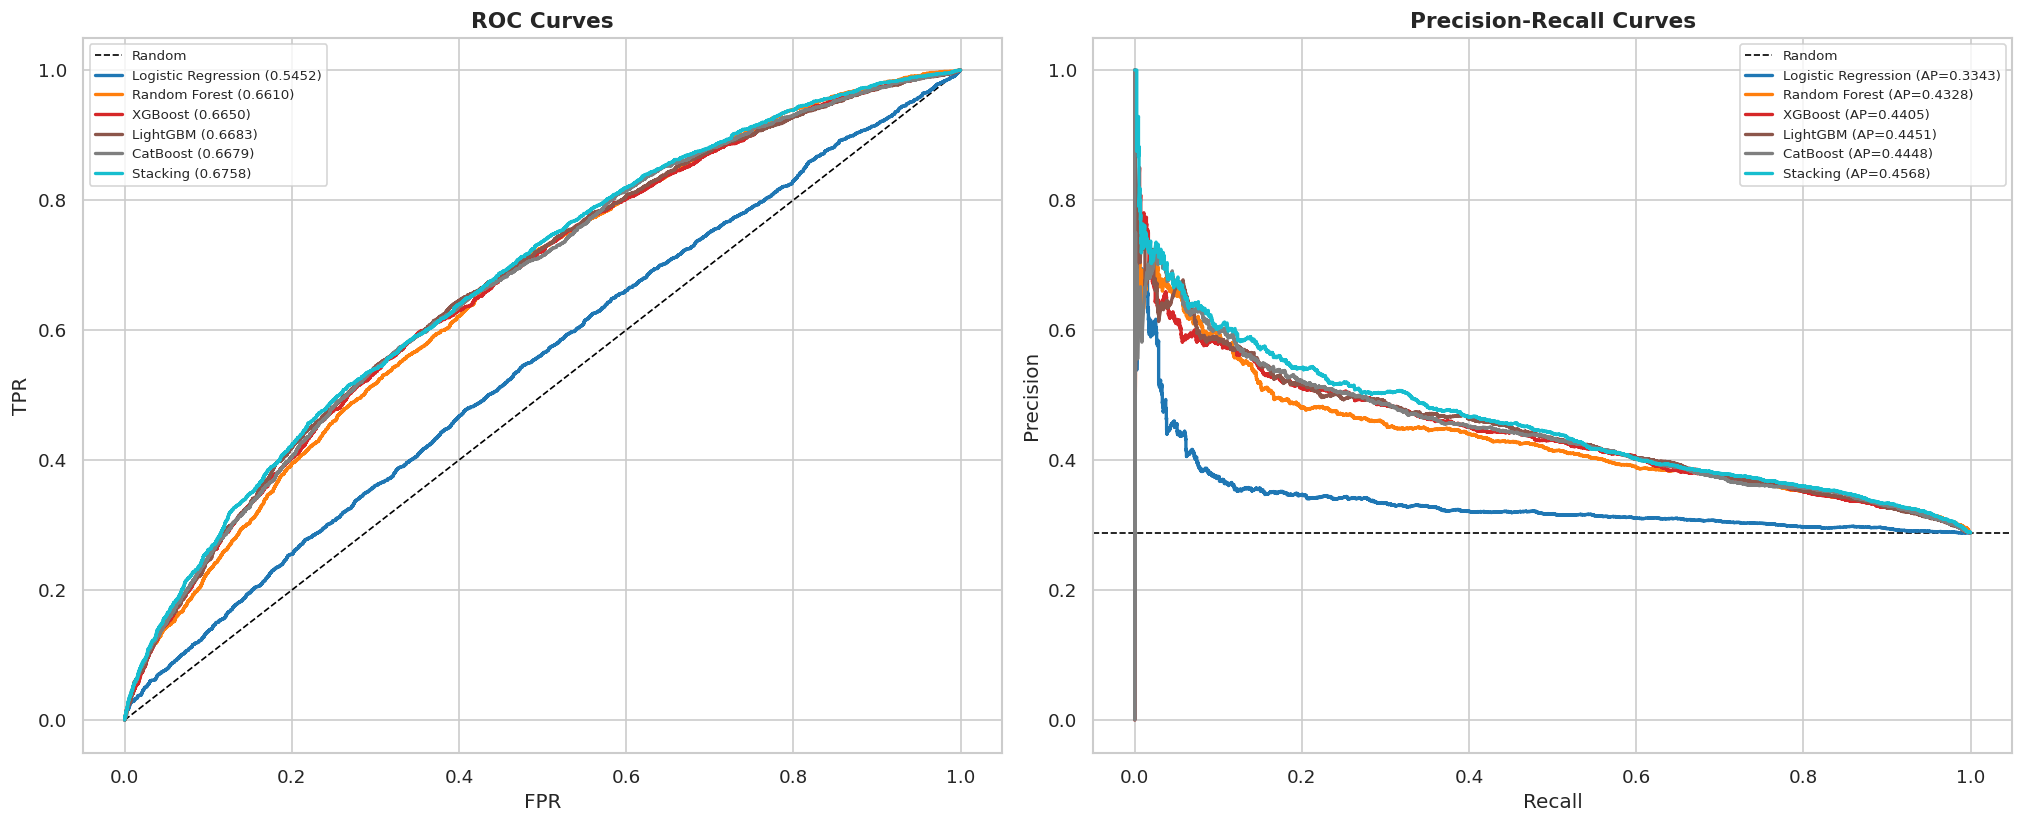

In [16]:
plot_models = ['Logistic Regression','Random Forest','XGBoost (Tuned)',
               'LightGBM (Tuned)','CatBoost (Tuned)','Stacking Ensemble']
colors = plt.cm.tab10(np.linspace(0, 0.9, len(plot_models)))
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
for mn, clr in zip(plot_models, colors):
    r = results[mn]; fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    axes[0].plot(fpr, tpr, lw=2, color=clr,
        label=f"{mn.replace(' (Tuned)','').replace(' Ensemble','').replace(' Avg','')} ({r['test_auc']:.4f})")
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves', fontweight='bold', fontsize=13); axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label='Random')
for mn, clr in zip(plot_models, colors):
    r = results[mn]; prec, rec, _ = precision_recall_curve(y_test, r['prob_test'])
    axes[1].plot(rec, prec, lw=2, color=clr,
        label=f"{mn.replace(' (Tuned)','').replace(' Ensemble','').replace(' Avg','')} (AP={r['ap']:.4f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight'); plt.show()


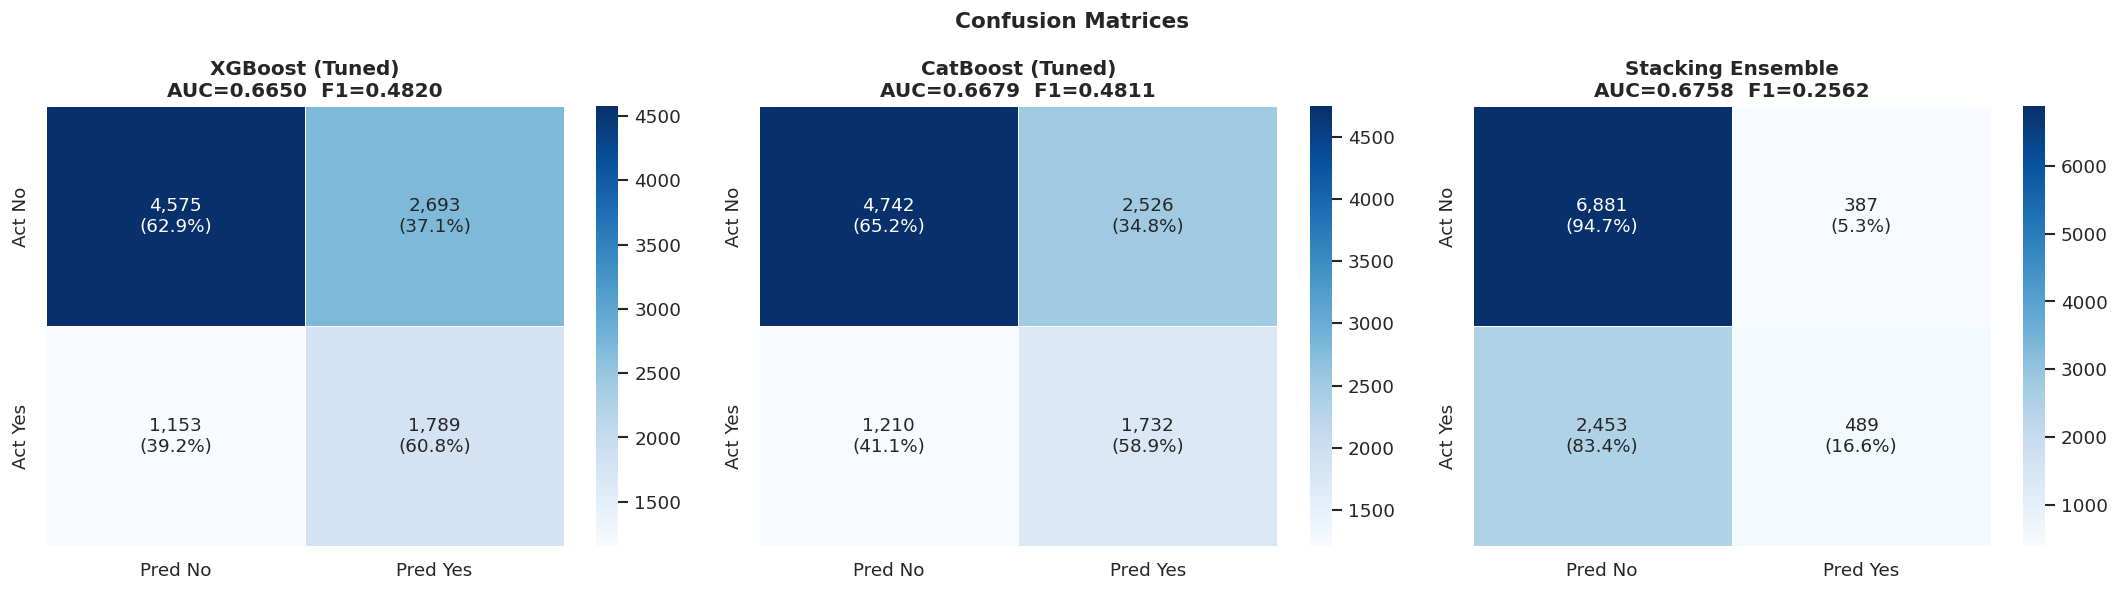

In [17]:
top3 = ['XGBoost (Tuned)','CatBoost (Tuned)','Stacking Ensemble']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mn in zip(axes, top3):
    r = results[mn]; pred = (r['prob_test']>=0.5).astype(int)
    cm = confusion_matrix(y_test, pred); pct = cm/cm.sum(axis=1, keepdims=True)
    annot = [[f'{cm[i,j]:,}\n({pct[i,j]:.1%})' for j in range(2)] for i in range(2)]
    sns.heatmap(cm, annot=np.array(annot), fmt='', cmap='Blues', ax=ax,
        xticklabels=['Pred No','Pred Yes'], yticklabels=['Act No','Act Yes'],
        linewidths=0.5, annot_kws={'size':11})
    ax.set_title(f'{mn}\nAUC={r["test_auc"]:.4f}  F1={r["f1"]:.4f}', fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


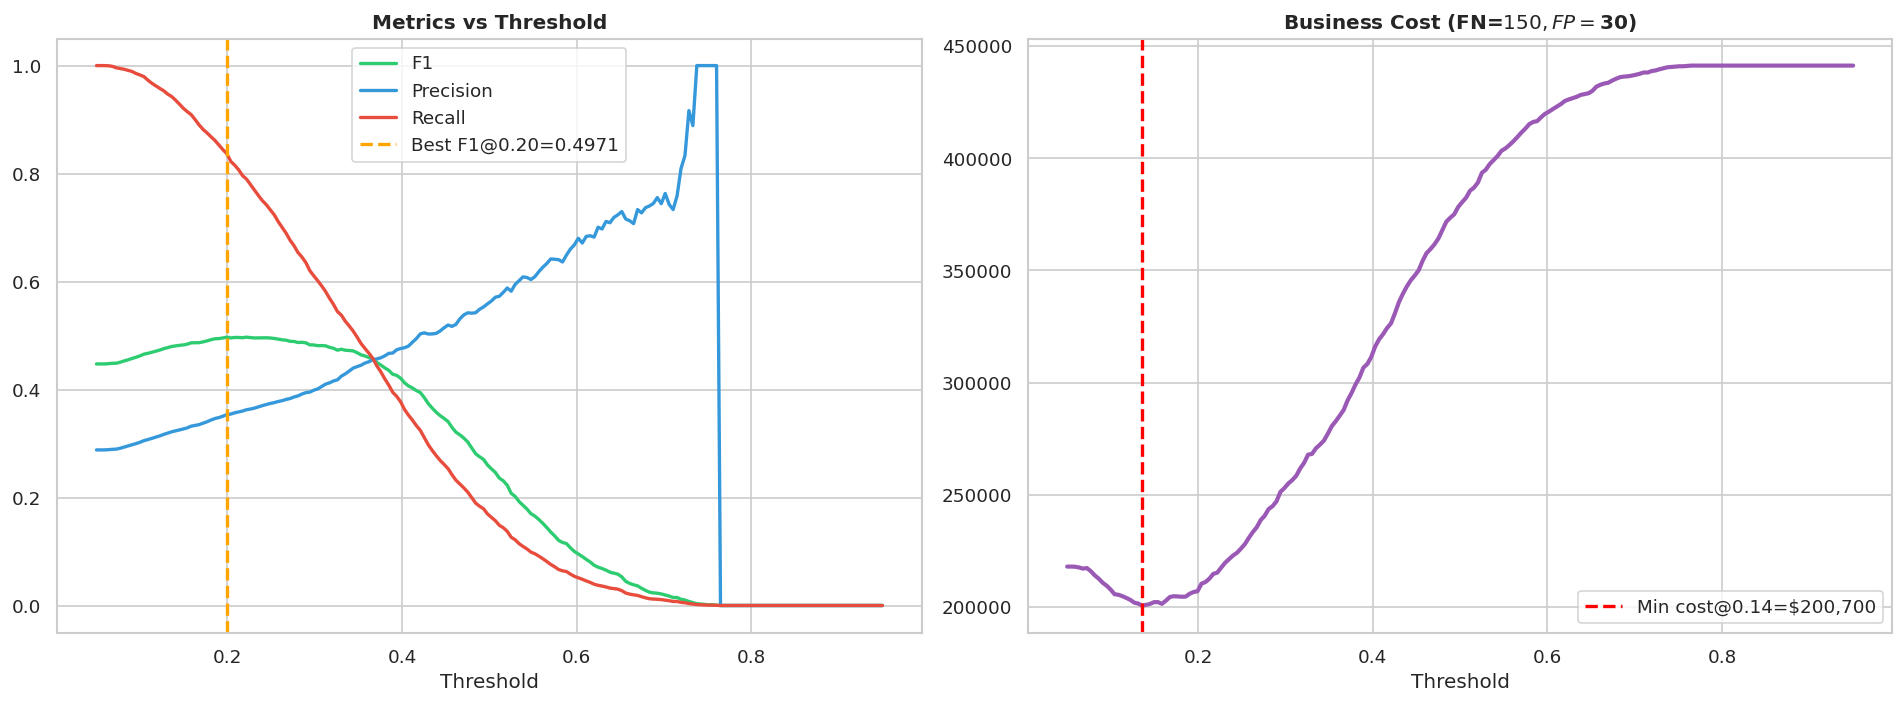

Best F1 threshold   : 0.20  F1=0.4971
Business threshold  : 0.14  Cost=$200,700


In [18]:
best_p = results['Stacking Ensemble']['prob_test']
ths = np.linspace(0.05, 0.95, 200)
f1s, precs, recs, costs = [], [], [], []
cost_fn, cost_fp = 150, 30
for t in ths:
    pred = (best_p>=t).astype(int)
    f1s.append(f1_score(y_test, pred, zero_division=0))
    precs.append(precision_score(y_test, pred, zero_division=0))
    recs.append(recall_score(y_test, pred, zero_division=0))
    tn,fp,fn,tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fn*cost_fn + fp*cost_fp)
best_f1_t = ths[np.argmax(f1s)]; best_biz_t = ths[np.argmin(costs)]
fig, (a1,a2) = plt.subplots(1,2,figsize=(16,6))
a1.plot(ths, f1s, lw=2, color='#2ecc71', label='F1')
a1.plot(ths, precs, lw=2, color='#3498db', label='Precision')
a1.plot(ths, recs, lw=2, color='#e74c3c', label='Recall')
a1.axvline(best_f1_t, color='orange', ls='--', lw=2, label=f'Best F1@{best_f1_t:.2f}={max(f1s):.4f}')
a1.set_title('Metrics vs Threshold', fontweight='bold'); a1.legend(); a1.set_xlabel('Threshold')
a2.plot(ths, costs, color='#9b59b6', lw=2.5)
a2.axvline(best_biz_t, color='red', ls='--', lw=2, label=f'Min cost@{best_biz_t:.2f}=${min(costs):,.0f}')
a2.set_title(f'Business Cost (FN=${cost_fn}, FP=${cost_fp})', fontweight='bold')
a2.legend(); a2.set_xlabel('Threshold')
plt.tight_layout(); plt.show()
print(f'Best F1 threshold   : {best_f1_t:.2f}  F1={max(f1s):.4f}')
print(f'Business threshold  : {best_biz_t:.2f}  Cost=${min(costs):,.0f}')


## 8. Feature Importance & Interpretability


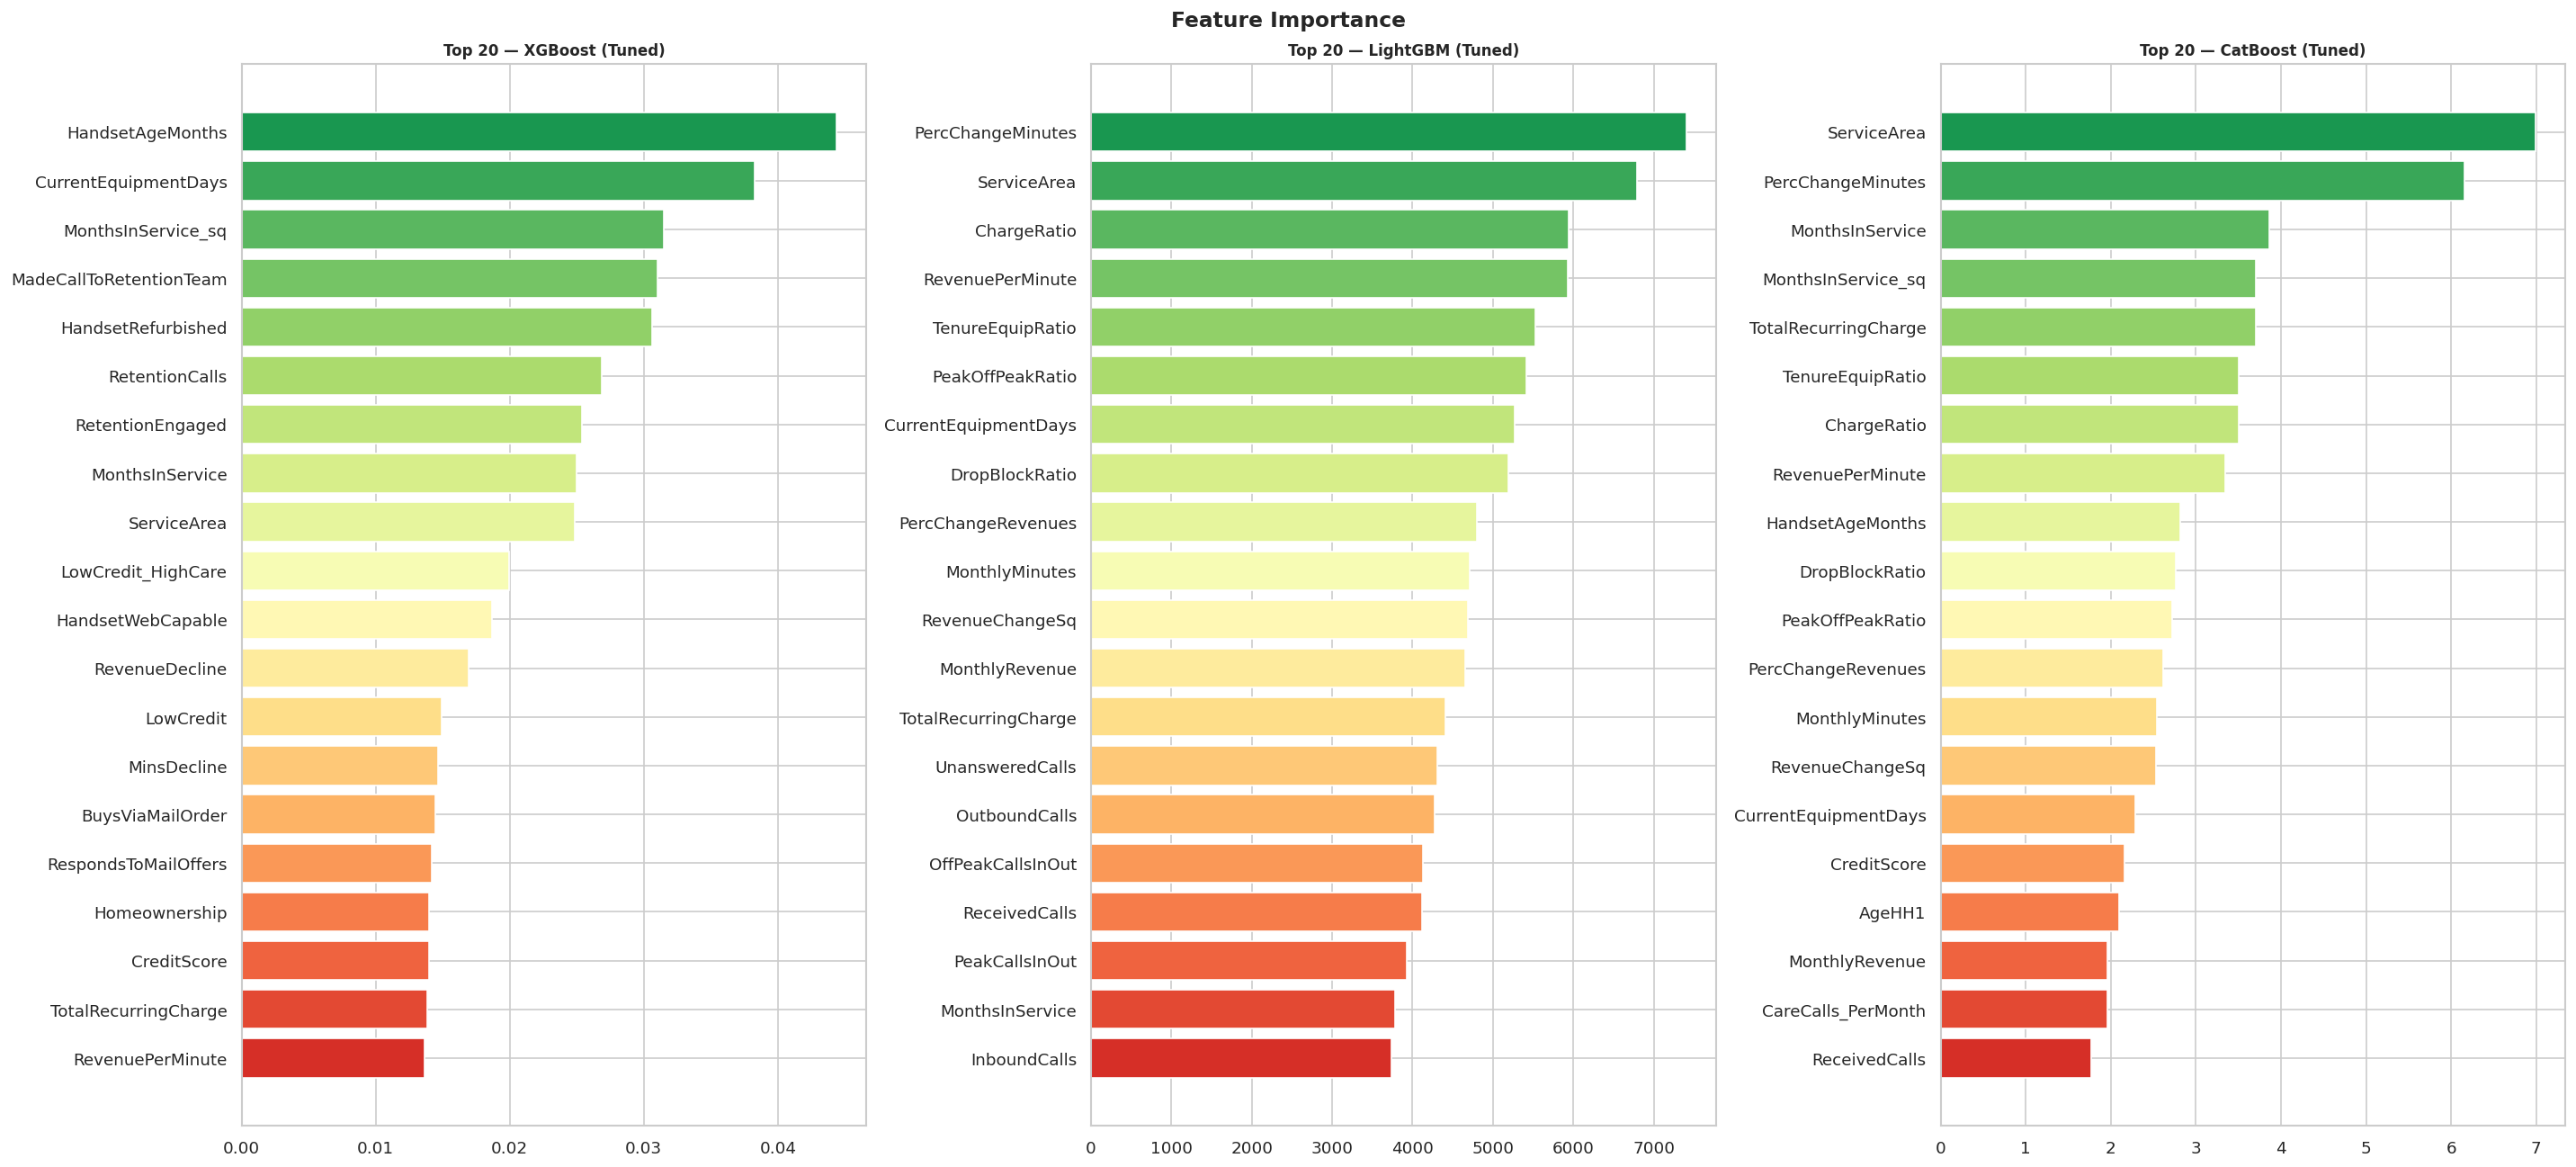

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 11))
for ax, mn, mo in [(axes[0],'XGBoost (Tuned)',xgb_t),
                    (axes[1],'LightGBM (Tuned)',lgbm_t),
                    (axes[2],'CatBoost (Tuned)',catb_t)]:
    imp = pd.Series(
        mo.feature_importances_ if hasattr(mo,'feature_importances_') else mo.get_feature_importance(),
        index=X_train.columns)
    top20 = imp.nlargest(20)
    ax.barh(top20.index[::-1], top20.values[::-1],
            color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,20))[::-1], edgecolor='white')
    ax.set_title(f'Top 20 — {mn}', fontweight='bold', fontsize=10)
plt.suptitle('Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()


Computing permutation importance...


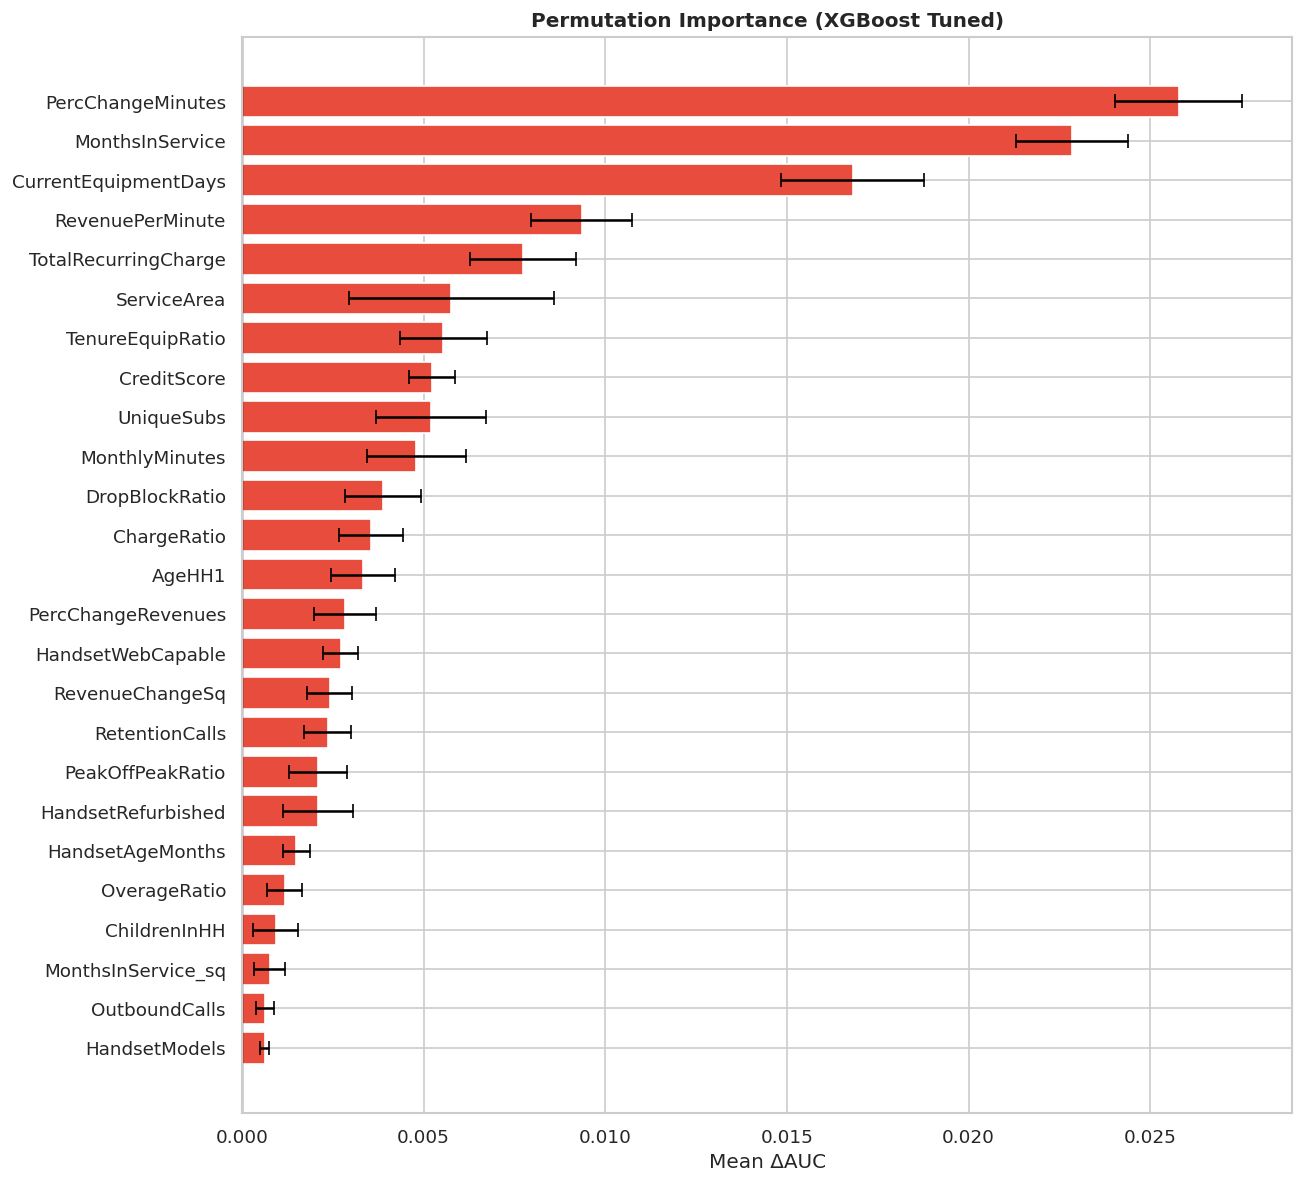

In [20]:
print('Computing permutation importance...')
perm = permutation_importance(xgb_t, X_test, y_test,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1)
perm_df = pd.DataFrame({'Feature':X_train.columns,
    'Importance':perm.importances_mean,'Std':perm.importances_std}
).sort_values('Importance', ascending=False).head(25)
fig, ax = plt.subplots(figsize=(11,10))
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1],
        color=['#e74c3c' if v>0 else '#95a5a6' for v in perm_df['Importance']][::-1],
        capsize=4, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Permutation Importance (XGBoost Tuned)', fontweight='bold', fontsize=12)
ax.set_xlabel('Mean ΔAUC')
plt.tight_layout(); plt.show()


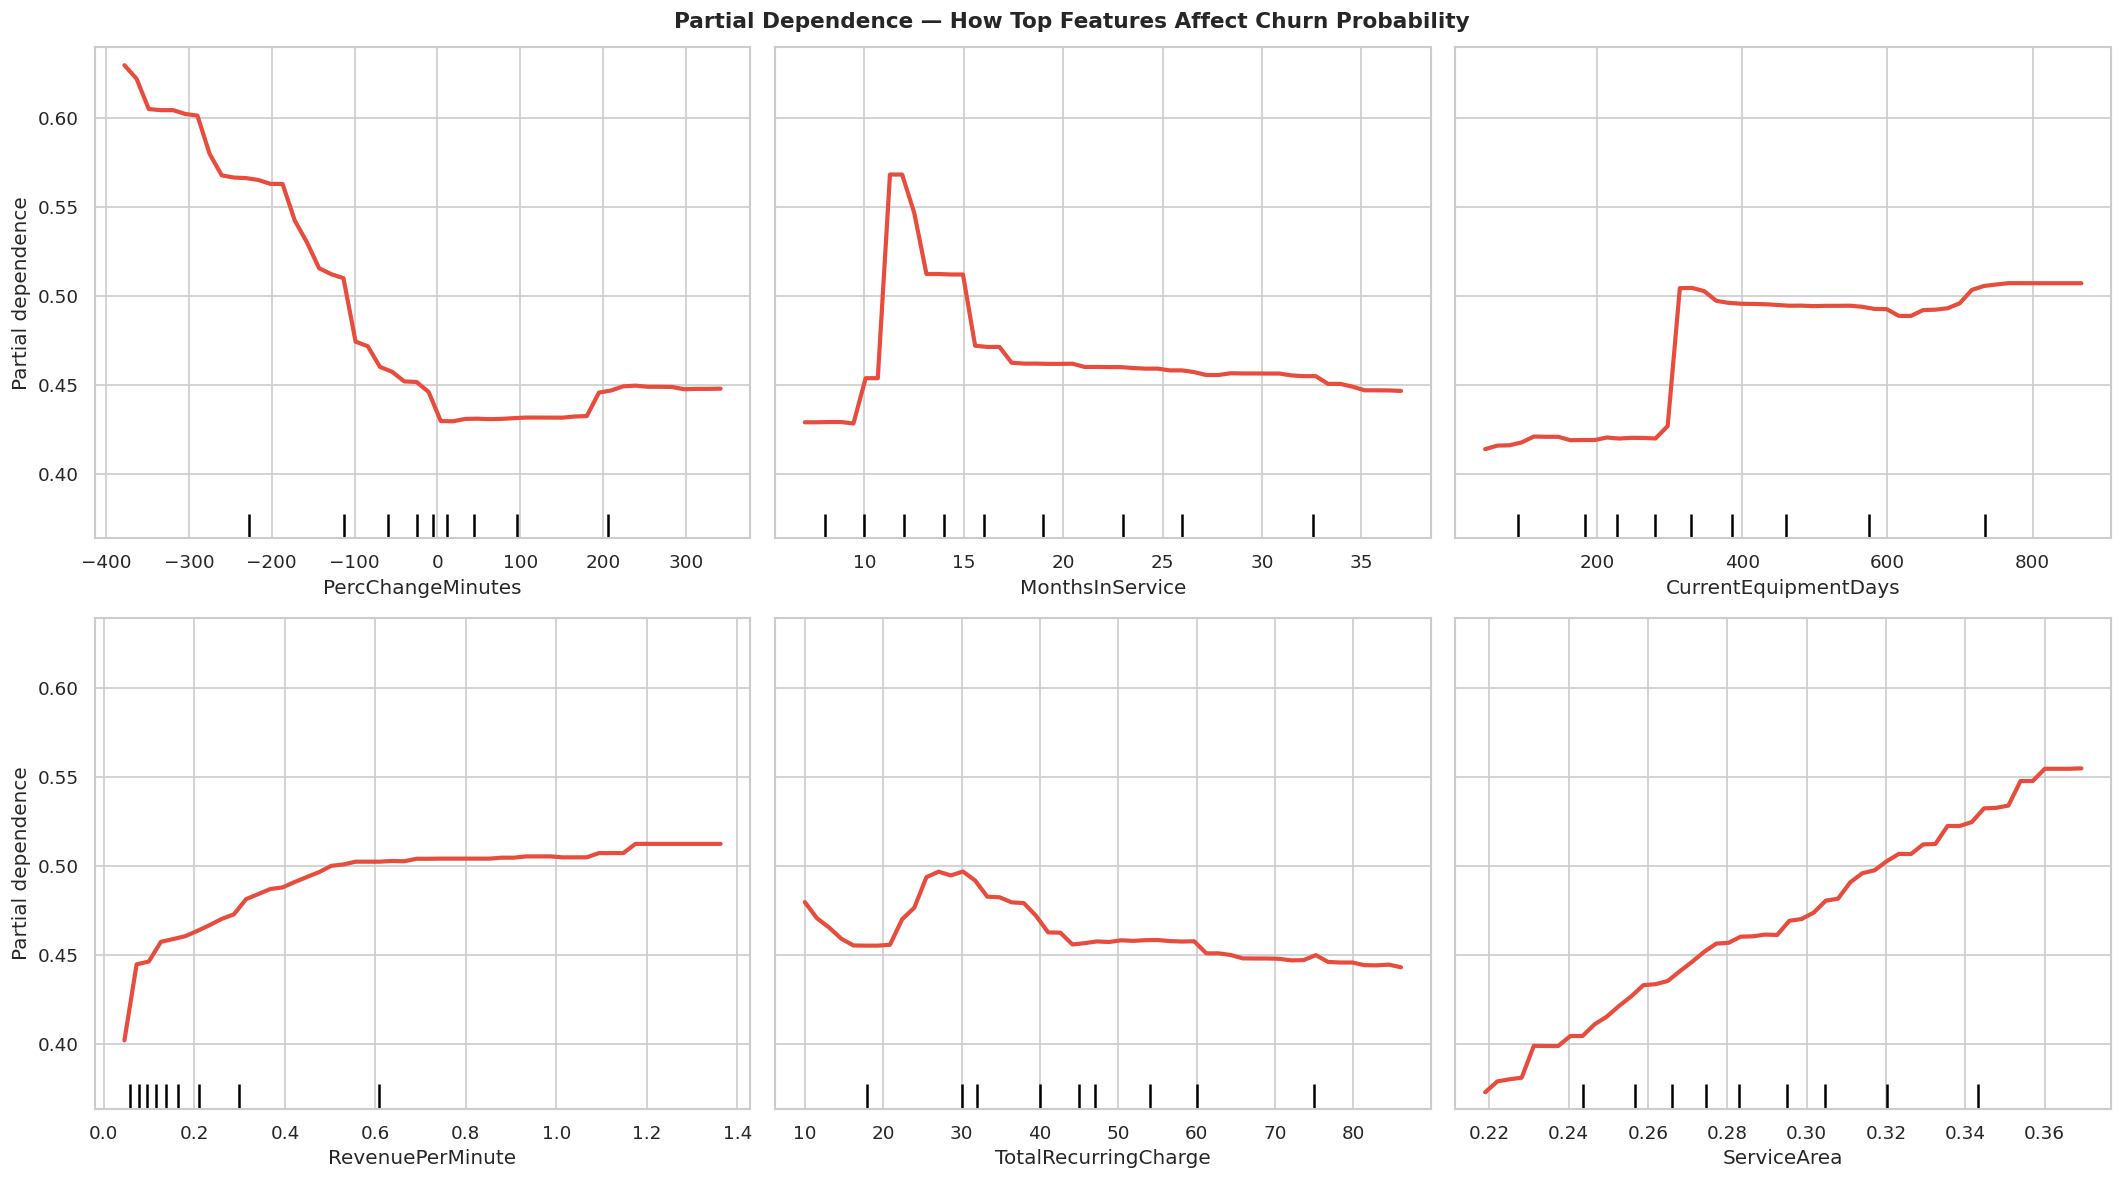

In [21]:
pdp_features = perm_df.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
PartialDependenceDisplay.from_estimator(xgb_t, X_test, pdp_features,
    ax=axes, grid_resolution=50, line_kw={'color':'#e74c3c','linewidth':2.5})
plt.suptitle('Partial Dependence — How Top Features Affect Churn Probability',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Business Insights & ROI


In [22]:
res_df = pd.DataFrame({'prob':results['Stacking Ensemble']['prob_test'],'actual':y_test})
def seg(p):
    if p>=0.70: return 'Very High (>=70%)'
    elif p>=0.50: return 'High (50-70%)'
    elif p>=0.30: return 'Medium (30-50%)'
    return 'Low (<30%)'
res_df['segment'] = res_df['prob'].apply(seg)
s = res_df.groupby('segment').agg(count=('actual','count'),
    churn_rate=('actual','mean'), avg_prob=('prob','mean')).reset_index()
s['pct'] = s['count']/s['count'].sum()
print('Customer Risk Segmentation:')
display(s.style.background_gradient(subset=['churn_rate'],cmap='RdYlGn_r')
    .format({'churn_rate':'{:.1%}','avg_prob':'{:.1%}','pct':'{:.1%}'}))
fig = px.treemap(s, path=['segment'], values='count', color='churn_rate',
    color_continuous_scale='RdYlGn_r', title='<b>Customer Risk Segments</b>')
fig.update_layout(height=380, template='plotly_white'); fig.show()


Customer Risk Segmentation:


,segment,count,churn_rate,avg_prob,pct
0,High (50-70%),837,55.0%,56.4%,8.2%
1,Low (<30%),5732,20.2%,18.6%,56.1%
2,Medium (30-50%),3602,36.0%,38.5%,35.3%
3,Very High (>=70%),39,74.4%,72.3%,0.4%


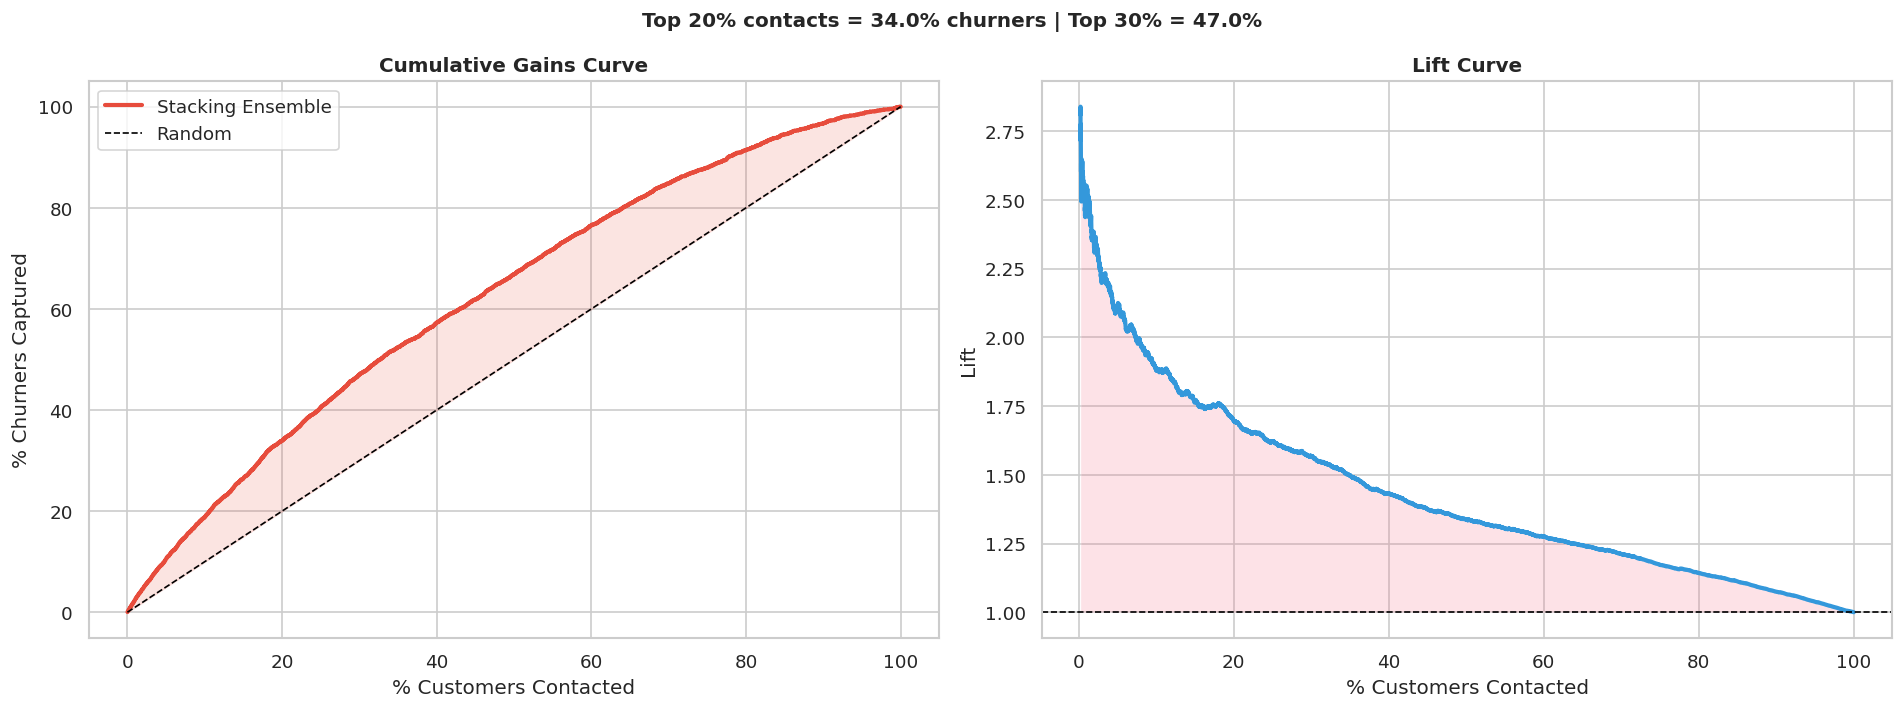

  BUSINESS ROI
  Avg 2yr CLV: $1163

  Top 20%: targeted=10,209 | churners_in_target~1,439 | retained~503
           cost=$510,450 | revenue_saved=$585,009 | ROI=15%

  Top 30%: targeted=15,314 | churners_in_target~1,992 | retained~697
           cost=$765,700 | revenue_saved=$810,639 | ROI=6%


In [23]:
bp = results['Stacking Ensemble']['prob_test']
srt = np.argsort(bp)[::-1]; sa = y_test[srt]
n = len(y_test); tc = y_test.sum()
pct_c = np.arange(1,n+1)/n*100
cum_c = np.cumsum(sa)/tc*100
lift  = (cum_c+1e-9)/(pct_c+1e-9)
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].plot(pct_c, cum_c, color='#e74c3c', lw=2.5, label='Stacking Ensemble')
axes[0].plot([0,100],[0,100],'k--',lw=1,label='Random')
axes[0].fill_between(pct_c, pct_c, cum_c, alpha=0.15, color='#e74c3c')
axes[0].set_xlabel('% Customers Contacted'); axes[0].set_ylabel('% Churners Captured')
axes[0].set_title('Cumulative Gains Curve', fontweight='bold'); axes[0].legend()
axes[1].plot(pct_c[20:], lift[20:], color='#3498db', lw=2.5)
axes[1].axhline(1,color='k',ls='--',lw=1)
axes[1].fill_between(pct_c[20:], 1, lift[20:], where=lift[20:]>1, alpha=0.2)
axes[1].set_xlabel('% Customers Contacted'); axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Curve', fontweight='bold')
t20 = np.sum(sa[:int(0.2*n)])/tc*100; t30 = np.sum(sa[:int(0.3*n)])/tc*100
plt.suptitle(f'Top 20% contacts = {t20:.1f}% churners | Top 30% = {t30:.1f}%',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('lift_curve.png',dpi=150,bbox_inches='tight'); plt.show()

avg_clv = df['MonthlyRevenue'].median()*24
n_total = len(df); ct = (df['Churn']=='Yes').sum()
print('='*65); print('  BUSINESS ROI'); print('='*65)
print(f'  Avg 2yr CLV: ${avg_clv:.0f}')
for pct in [0.20,0.30]:
    nt = int(pct*n_total)
    fc = np.sum(sa[:int(pct*n)])/n
    ch = int(fc*ct); ret = int(ch*0.35)
    rev = ret*avg_clv; cost = nt*50
    print(f'\n  Top {pct:.0%}: targeted={nt:,} | churners_in_target~{ch:,} | retained~{ret:,}')
    print(f'           cost=${cost:,.0f} | revenue_saved=${rev:,.0f} | ROI={(rev-cost)/cost*100:.0f}%')
print('='*65)


In [24]:
print('='*70); print('  KEY INSIGHTS'); print('='*70)
mrt = df.groupby('MadeCallToRetentionTeam')['y'].mean()
print(f'  MadeCallToRetentionTeam: Yes={mrt["Yes"]:.1%}  No={mrt["No"]:.1%}  (strongest predictor)')
print(f'  CustomerCareCalls >2   : {df[df["CustomerCareCalls"]>2]["y"].mean():.1%} vs avg {df["y"].mean():.1%}')
print(f'  Revenue decline >10%   : {df[df["PercChangeRevenues"]<-10]["y"].mean():.1%} churn rate')
print(f'  Low credit (6-7)       : {df[df["CreditRating"].isin(["6-VeryLow","7-Lowest"])]["y"].mean():.1%}')
print('\n  ACTIONS:')
for i,a in enumerate(['Deploy model weekly -> score all -> contact top 20-30%',
    'Auto-flag >=3 care calls in 30 days for proactive outreach',
    'Prioritize retention offers for customers who already called retention',
    'Tailored offers for low credit-rating segments',
    'Dedicated onboarding for first 12 months (highest risk window)',
    'Improve network in high drop/blocked call areas'],1):
    print(f'  {i}. {a}')


  KEY INSIGHTS
  MadeCallToRetentionTeam: Yes=45.0%  No=28.2%  (strongest predictor)
  CustomerCareCalls >2   : 24.8% vs avg 28.8%
  Revenue decline >10%   : 30.3% churn rate
  Low credit (6-7)       : 28.4%

  ACTIONS:
  1. Deploy model weekly -> score all -> contact top 20-30%
  2. Auto-flag >=3 care calls in 30 days for proactive outreach
  3. Prioritize retention offers for customers who already called retention
  4. Tailored offers for low credit-rating segments
  5. Dedicated onboarding for first 12 months (highest risk window)
  6. Improve network in high drop/blocked call areas


## 10. Save Artifacts & Final Summary


In [25]:
import pickle, json
with open('notebook_artifacts.pkl','wb') as f:
    pickle.dump({'xgb_tuned':xgb_t,'lgbm_tuned':lgbm_t,'catb_tuned':catb_t,
        'rf':rf,'meta':meta,'scaler':scaler,'te_enc':te_enc,'le_enc':le_enc,
        'medians':meds,'features':list(X_train.columns),
        'best_thresh':float(best_biz_t),'best_f1_thresh':float(best_f1_t)},f)
best=results['Stacking Ensemble']
summary={'best_test_auc':float(best['test_auc']),'best_f1':float(best['f1']),
    'best_ap':float(best['ap']),'optimal_threshold':float(best_biz_t),
    'n_features':int(X_train.shape[1]),
    'all_models':{n:{'test_auc':float(r['test_auc']),'f1':float(r['f1']),'ap':float(r['ap'])}
        for n,r in results.items()}}
with open('notebook_summary.json','w') as f: json.dump(summary,f,indent=2)
print('Saved: notebook_artifacts.pkl, notebook_summary.json')


Saved: notebook_artifacts.pkl, notebook_summary.json


In [26]:
best=results['Stacking Ensemble']
print('*'*68)
print('   FINAL RESULTS — STACKING ENSEMBLE'.center(68))
print('*'*68)
print(f'  Models   : XGBoost + LightGBM + CatBoost + RF  ->  LR meta')
print(f'  Features : {X_train.shape[1]} (raw + engineered + target-encoded ServiceArea)')
print(f'  Test AUC : {best["test_auc"]:.4f}')
print(f'  F1 Score : {best["f1"]:.4f}')
print(f'  Avg Prec : {best["ap"]:.4f}')
print(f'  Precision: {best["precision"]:.4f}')
print(f'  Recall   : {best["recall"]:.4f}')
print(f'  Top 20%  : {t20:.1f}% of churners captured ({t20/20:.1f}x lift)')
print('*'*68)
print('\nAll models:')
display(metrics_df.style.background_gradient(subset=['Test AUC'],cmap='YlGn')
    .format(precision=4).hide(axis='index'))


********************************************************************
                   FINAL RESULTS — STACKING ENSEMBLE                
********************************************************************
  Models   : XGBoost + LightGBM + CatBoost + RF  ->  LR meta
  Features : 80 (raw + engineered + target-encoded ServiceArea)
  Test AUC : 0.6758
  F1 Score : 0.2562
  Avg Prec : 0.4568
  Precision: 0.5582
  Recall   : 0.1662
  Top 20%  : 34.0% of churners captured (1.7x lift)
********************************************************************

All models:


Model,Test AUC,F1,Precision,Recall,Avg Precision
Stacking Ensemble,0.6758,0.2562,0.5582,0.1662,0.4568
Weighted Avg Ensemble,0.6757,0.4735,0.4182,0.5455,0.4563
CatBoost (base),0.6686,0.4772,0.3972,0.5976,0.4430
LightGBM (Tuned),0.6683,0.4739,0.4234,0.5381,0.4451
CatBoost (Tuned),0.6679,0.4811,0.4068,0.5887,0.4448
XGBoost (base),0.6668,0.4799,0.4022,0.5948,0.4437
XGBoost (Tuned),0.6650,0.4820,0.3992,0.6081,0.4405
Random Forest,0.6610,0.4642,0.4054,0.5428,0.4328
LightGBM (base),0.6599,0.4426,0.4250,0.4616,0.4347
Logistic Regression,0.5452,0.4043,0.3129,0.5710,0.3343
